In [12]:
from satdatakit import read, compute_index, Pipeline
import matplotlib.pyplot as plt
import numpy as np
import os

In [13]:
# Solo si necesitas regenerar datos

In [14]:
ds = read("/workspace/data/sentinel2_test.tif")
print(f"✅ GeoTIFF: {ds.n_bands} bandas")

✅ GeoTIFF: 10 bandas


In [15]:
ds_hdf = read("/workspace/data/sentinel2_test.h5")

In [16]:
ds_ndvi = compute_index(ds, "NDVI")
ds_ndwi = compute_index(ds, "NDWI")
ds_evi = compute_index(ds, "EVI")
print(f"✅ Índices calculados")

✅ Índices calculados


In [17]:
result = Pipeline().read("/workspace/data/sentinel2_test.tif").select_bands(["B04", "B08"]).compute_index("NDVI")
print(f"✅ Pipeline: {result.dataset.bands}")

✅ Pipeline: ['B04', 'B08', 'NDVI']


In [18]:
ds_nc = read("/workspace/data/sentinel2_test.nc")
ds_hdf = read("/workspace/data/sentinel2_test.h5")
print(f"✅ NetCDF: {ds_nc.n_bands} bandas")
print(f"✅ HDF5: {ds_hdf.n_bands} bandas")

✅ NetCDF: 10 bandas
✅ HDF5: 10 bandas


In [19]:
os.makedirs("/workspace/output", exist_ok=True)
ds_ndvi.to_geotiff("/workspace/output/ndvi_export.tif")
ds_ndvi.to_netcdf("/workspace/output/ndvi_export.nc")
print("✅ Exportado")

✅ Exportado


In [20]:
# ... código de matplotlib ...

In [21]:
ds_hdf = read("/workspace/data/sentinel2_test.h5")
print(f"✅ HDF5: {ds_hdf.n_bands} bandas, format={ds_hdf.source_format}")

✅ HDF5: 10 bandas, format=hdf5


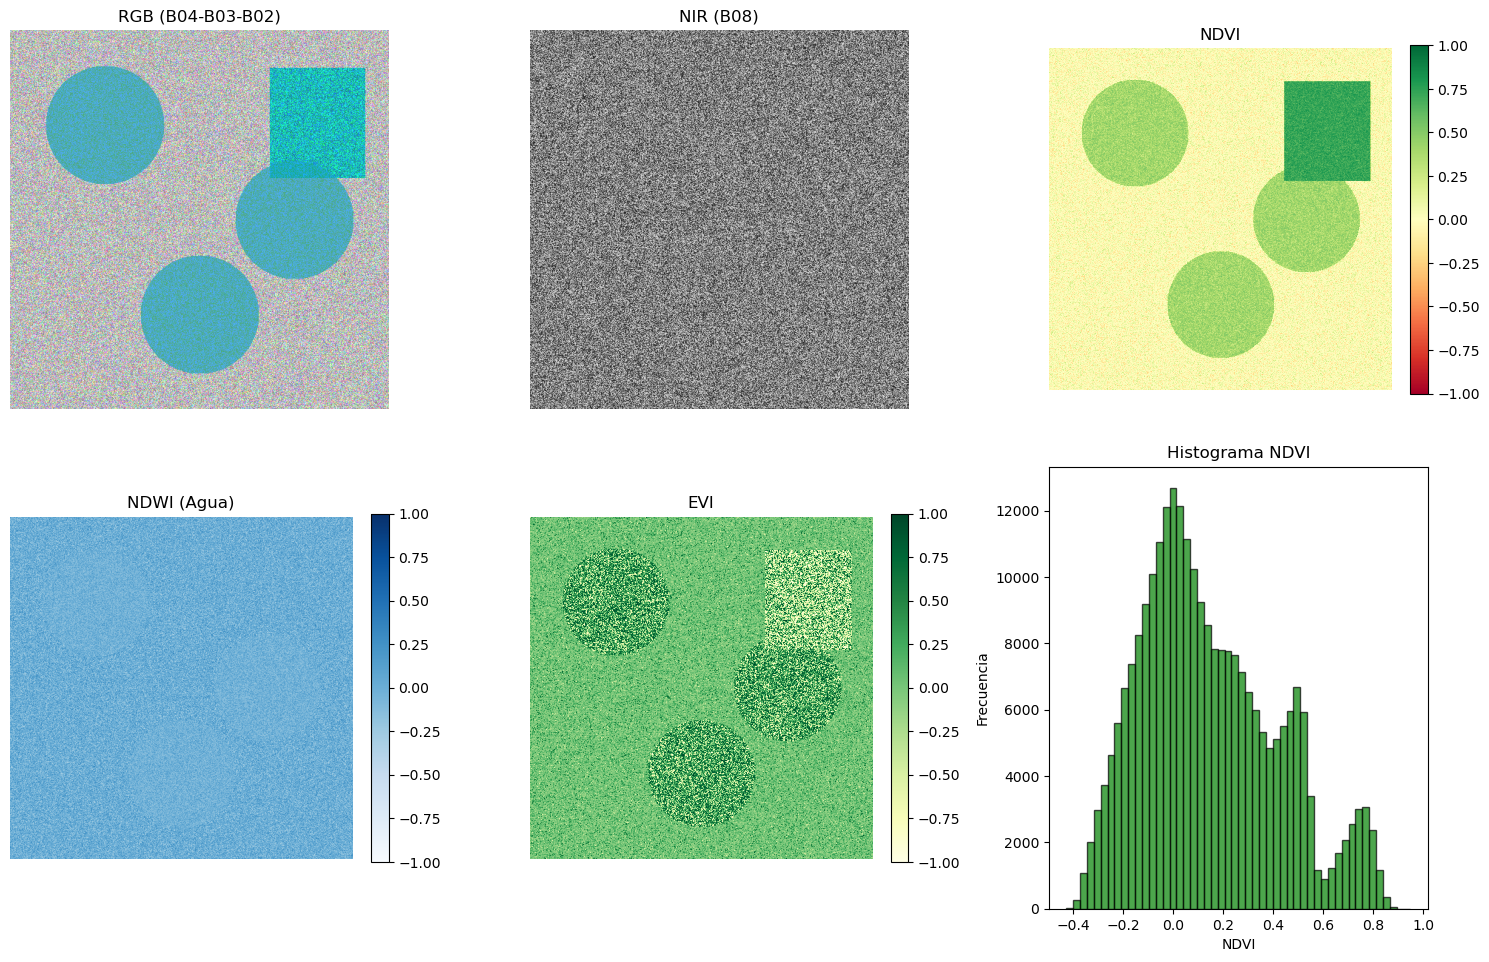

✅ Visualización guardada en /workspace/output/satdatakit_results.png


In [22]:
# ============================================================
# PRUEBA 7: VISUALIZACIÓN COMPLETA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# RGB falso color (B04=Red, B03=Green, B02=Blue)
rgb = np.stack([
    ds["B04"].values,
    ds["B03"].values,
    ds["B02"].values,
], axis=-1)
rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

axes[0, 0].imshow(rgb)
axes[0, 0].set_title("RGB (B04-B03-B02)")
axes[0, 0].axis("off")

# NIR
axes[0, 1].imshow(ds["B08"].values, cmap="gray")
axes[0, 1].set_title("NIR (B08)")
axes[0, 1].axis("off")

# NDVI
ndvi = ds_ndvi["NDVI"].values
im = axes[0, 2].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0, 2].set_title("NDVI")
axes[0, 2].axis("off")
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

# NDWI
ndwi = ds_ndwi["NDWI"].values
im = axes[1, 0].imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
axes[1, 0].set_title("NDWI (Agua)")
axes[1, 0].axis("off")
plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

# EVI
evi = ds_evi["EVI"].values
im = axes[1, 1].imshow(evi, cmap="YlGn", vmin=-1, vmax=1)
axes[1, 1].set_title("EVI")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

# Histograma NDVI
axes[1, 2].hist(ndvi.flatten(), bins=50, color="green", alpha=0.7, edgecolor="black")
axes[1, 2].set_title("Histograma NDVI")
axes[1, 2].set_xlabel("NDVI")
axes[1, 2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("/workspace/output/satdatakit_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Visualización guardada en /workspace/output/satdatakit_results.png")

In [23]:
# ============================================================
# PRUEBA 8: EXPORTACIÓN
# ============================================================

import os
os.makedirs("/workspace/output", exist_ok=True)

# Exportar NDVI a GeoTIFF
ds_ndvi.to_geotiff("/workspace/output/ndvi_export.tif")
print("✅ NDVI exportado a GeoTIFF")

# Exportar a NetCDF
ds_ndvi.to_netcdf("/workspace/output/ndvi_export.nc")
print("✅ NDVI exportado a NetCDF")

print("\n" + "=" * 60)
print("TODAS LAS PRUEBAS COMPLETADAS EXITOSAMENTE")
print("=" * 60)
print("\nResumen:")
print("  • GeoTIFF: lectura + escritura")
print("  • NetCDF: lectura + escritura")
print("  • HDF5: lectura")
print("  • Índices: NDVI, NDWI, EVI")
print("  • Pipeline: read → select → compute_index")
print("  • Visualización: RGB, NIR, NDVI, NDWI, EVI + histograma")

✅ NDVI exportado a GeoTIFF
✅ NDVI exportado a NetCDF

TODAS LAS PRUEBAS COMPLETADAS EXITOSAMENTE

Resumen:
  • GeoTIFF: lectura + escritura
  • NetCDF: lectura + escritura
  • HDF5: lectura
  • Índices: NDVI, NDWI, EVI
  • Pipeline: read → select → compute_index
  • Visualización: RGB, NIR, NDVI, NDWI, EVI + histograma
